In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
from xgboost import XGBClassifier


df = pd.read_csv('cs-training.csv')
df = df.drop(columns=['Unnamed: 0'])
df.head()
df.shape
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [10]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


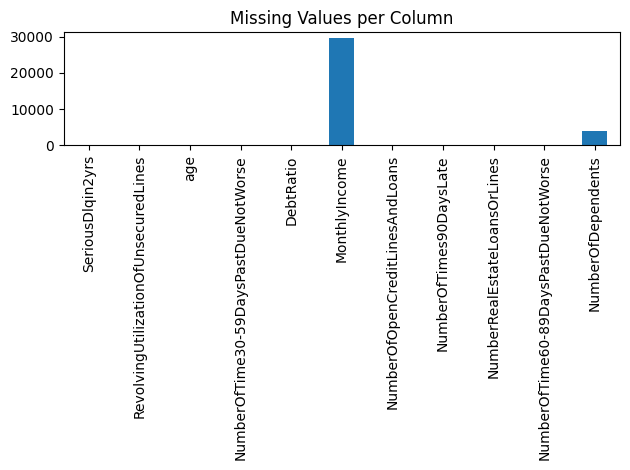

In [11]:
df.isnull().sum().plot(kind='bar')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

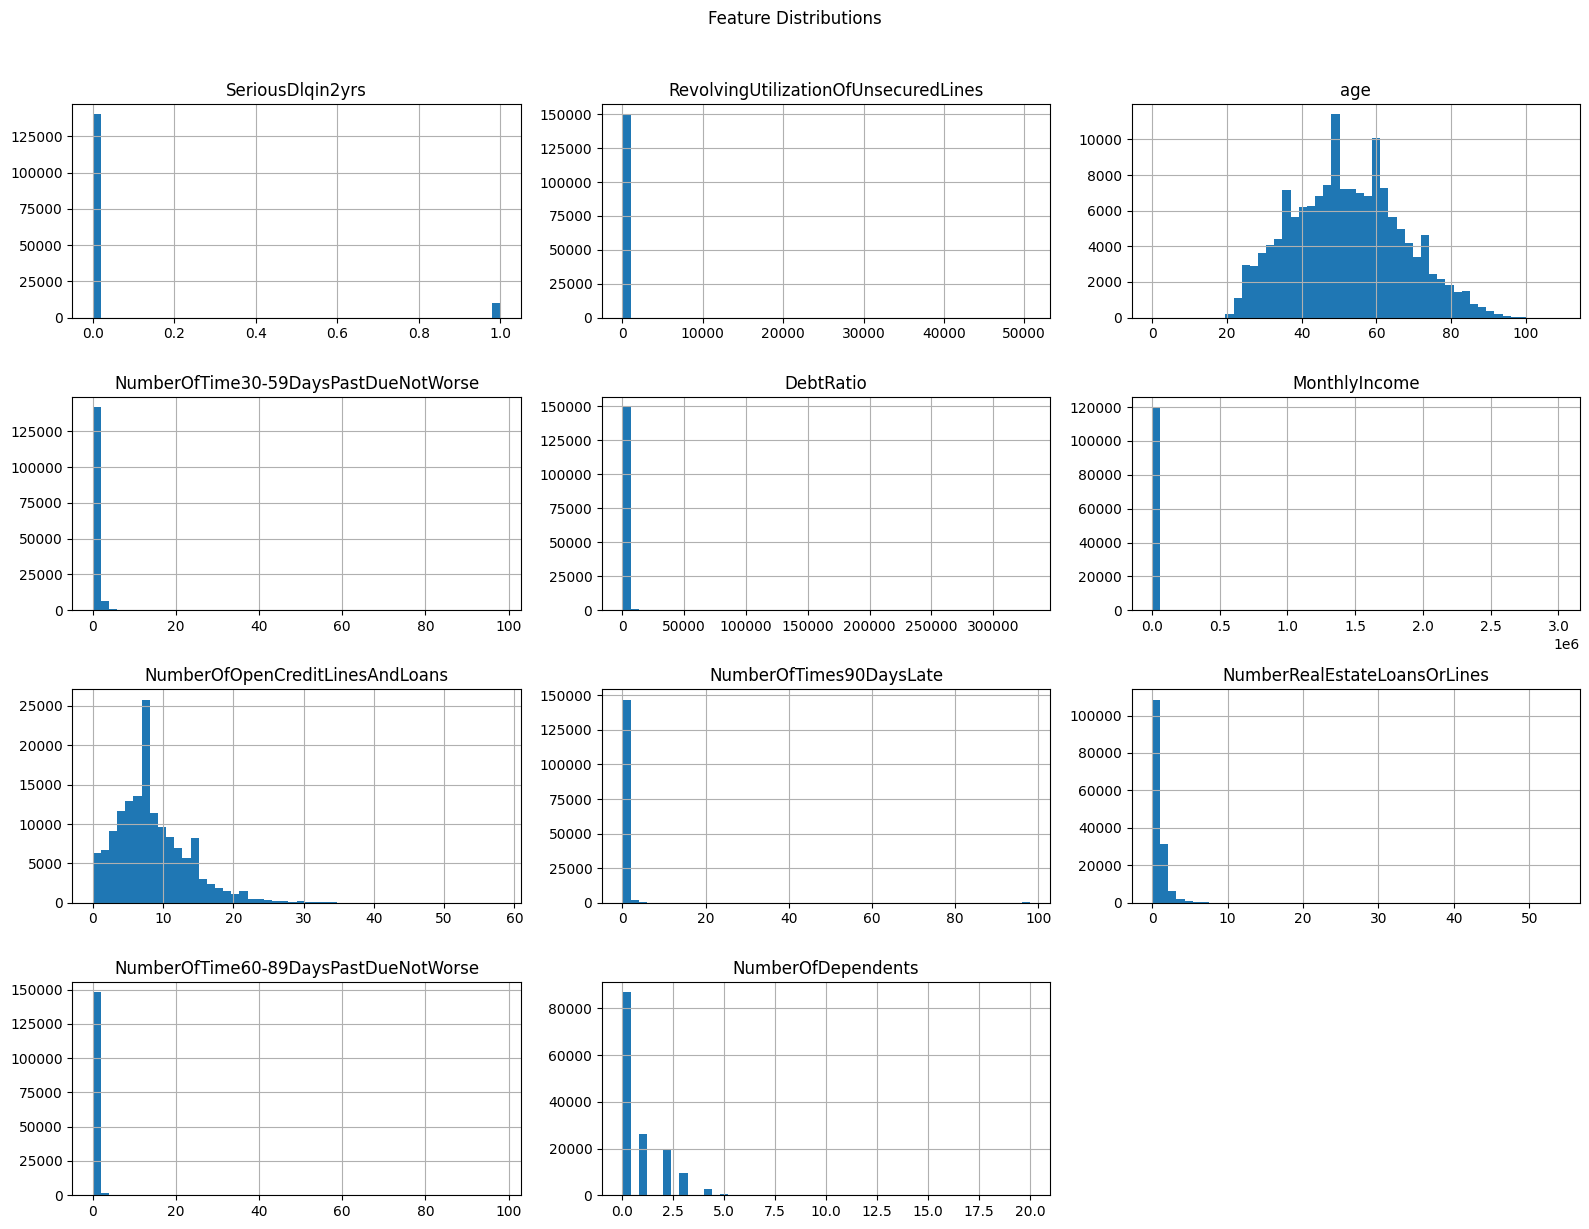

In [12]:
df.hist(figsize=(16, 12), bins=50)
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse']

df[late_cols] = df[late_cols].replace(98, np.nan)

In [14]:
for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

In [15]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())
df[late_cols] = df[late_cols].fillna(0)

In [17]:
df.isnull().sum()

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [18]:
# Total number of times late across all categories
df['TotalLatePayments'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                            df['NumberOfTimes90DaysLate'] +
                            df['NumberOfTime60-89DaysPastDueNotWorse'])

# Income per dependent (financial pressure indicator)
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

# Debt to income ratio (more meaningful than raw debt ratio)
df['DebtToIncome'] = df['DebtRatio'] * df['MonthlyIncome']

# Flag for people with zero income
df['ZeroIncome'] = (df['MonthlyIncome'] == 0).astype(int)

In [19]:
df[['TotalLatePayments', 'IncomePerDependent', 'DebtToIncome', 'ZeroIncome']].describe()

,TotalLatePayments,IncomePerDependent,DebtToIncome,ZeroIncome
count,150000.000000,150000.000000,1.500000e+05,150000.000000
mean,0.409953,4433.607958,1.610361e+06,0.010893
std,1.992455,3230.285866,4.782747e+06,0.103801
min,0.000000,0.000000,0.000000e+00,0.000000
25%,0.000000,2151.000000,7.728930e+02,0.000000
50%,0.000000,4000.000000,2.101669e+03,0.000000
75%,0.000000,5400.000000,4.772299e+03,0.000000
max,288.000000,25000.000000,2.688682e+07,1.000000


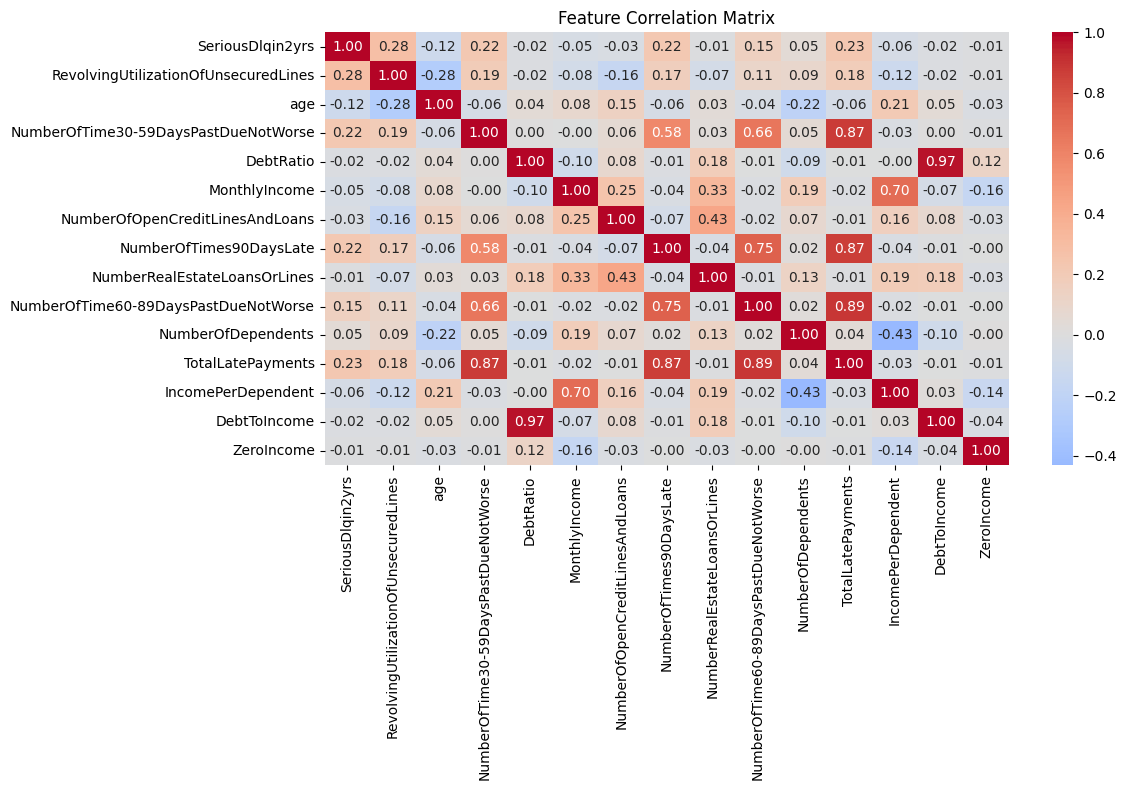

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [21]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(120000, 14) (30000, 14)


In [22]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Evaluate
lr_preds = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_preds)
print(f'Logistic Regression AUC-ROC: {lr_auc:.4f}')

Logistic Regression AUC-ROC: 0.8556


In [23]:
# Calculate scale_pos_weight to handle class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'scale_pos_weight: {scale:.2f}')

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc'
)

xgb.fit(X_train, y_train)

# Evaluate
xgb_preds = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_preds)
print(f'XGBoost AUC-ROC: {xgb_auc:.4f}')

scale_pos_weight: 13.96
XGBoost AUC-ROC: 0.8667


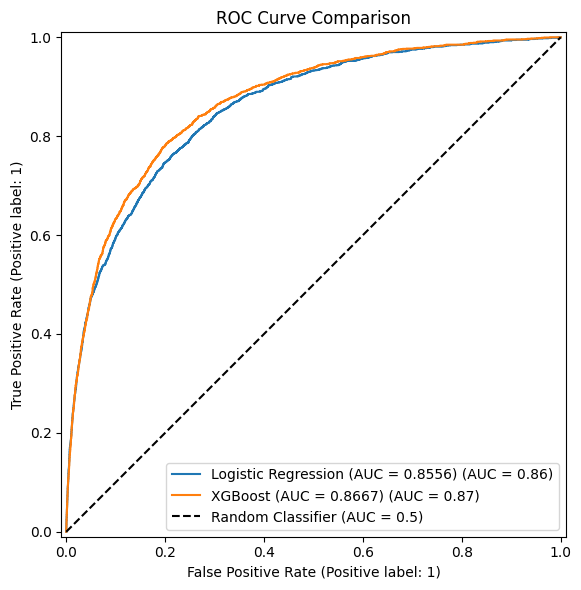

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_preds, name=f'Logistic Regression (AUC = {lr_auc:.4f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_preds, name=f'XGBoost (AUC = {xgb_auc:.4f})', ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

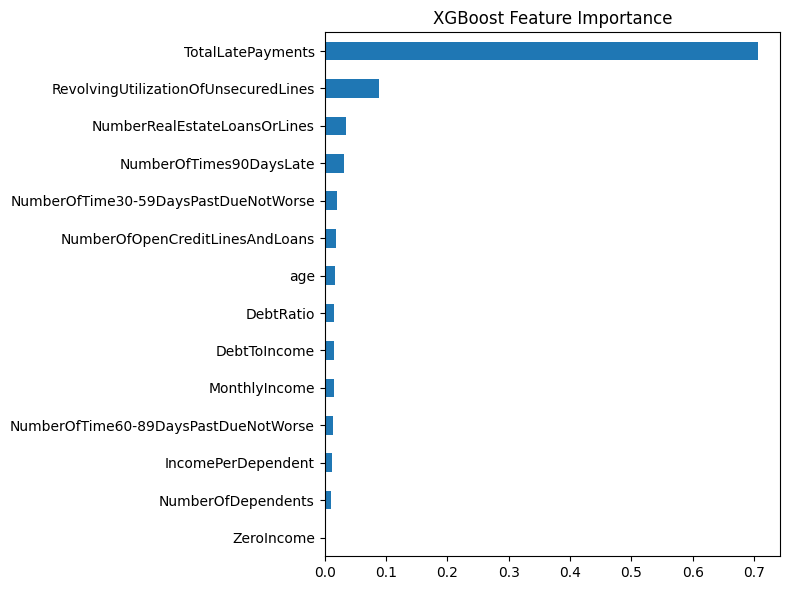

In [25]:
feat_importance = pd.Series(xgb.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

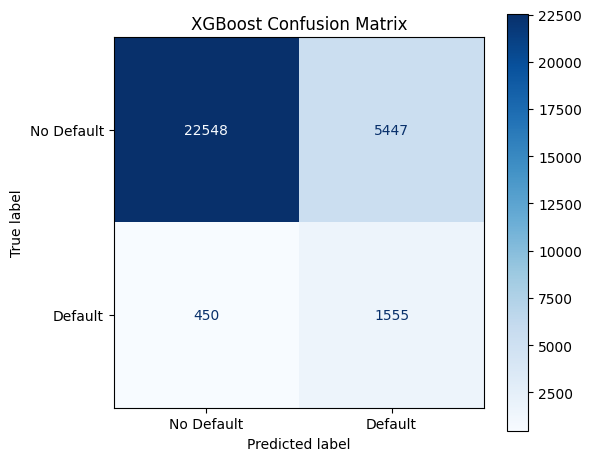

              precision    recall  f1-score   support

  No Default       0.98      0.81      0.88     27995
     Default       0.22      0.78      0.35      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.85     30000



In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

xgb_labels = xgb.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, xgb_labels, ax=ax,
                                         display_labels=['No Default', 'Default'],
                                         cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, xgb_labels, target_names=['No Default', 'Default']))

## Conclusions

- Dataset: 150,000 individuals, 6.7% default rate (heavily imbalanced)
- Handled missing values via median imputation and outlier capping at 99th percentile
- Engineered 4 new features, of which TotalLatePayments became the single most
  important predictor in the model (importance: 0.70)
- Logistic Regression baseline AUC-ROC: 0.8556
- XGBoost final model AUC-ROC: 0.8667
- Model prioritises recall (0.78) over precision (0.22) for the default class,
  consistent with real-world credit risk appetite where missing a defaulter
  is more costly than rejecting a good customer
- Key risk drivers: total late payment history and revolving credit utilization